## Word2Vec Embedding Algorithm.
It learns embeddings using:
- Skip-gram (predict context from center)

#### Skip-gram Objective Function

Given a center word 

$$
\max_{\theta} \sum_{t=1}^{T} 
\sum_{\substack{-k \le j \le k \\ j \ne 0}}
\log P(w_{t+j} \mid w_t)
$$

Where: 
$$
P(w_o \mid w_i) =
\frac{
\exp\left( v_{w_o}^{\top} v_{w_i} \right)
}{
\sum_{w=1}^{V} \exp\left( v_{w}^{\top} v_{w_i} \right)
}
$$


This is computed using:

Negative Sampling: where a K set of randomly selected words are used not full softmax.

#### How are Embeddings updated
1. Compute: 
$$
\hat{y} = \sigma\left( v_{w_o}^{\top} v_{w_i} \right)
$$

2. Compute Gradients:
$$
g = (\hat{y} - 1)\, v_{w_i}
$$

3. Update
$$
v_{w_o} := v_{w_o} - \eta\, g
$$


In [73]:
from datasets import load_dataset
import pandas as pd
import gensim
from gensim.models import Word2Vec
import nltk 
nltk.download('punkt')
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [74]:

dataset = load_dataset('ag_news')
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

In [75]:
from tensorflow.keras.utils import to_categorical

X_train = train_df['text'].astype(str)
X_test = test_df['text'].astype(str)
y_train = train_df['label']
y_test = test_df['label']

num_classes = 4
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

In [76]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 40000
max_len = 200

tokenizer = Tokenizer(num_words = vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert texts → integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq,maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

word_index = tokenizer.word_index
index_to_word = {v: k for k,v in word_index.items()}


In [77]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentences = [text_to_word_sequence(t) for t in X_train]

w2v_dim = 128

w2v_model = Word2Vec(
    sentences = sentences,
    vector_size = w2v_dim,
    window=5,
    min_count = 3,
    workers = 4,
    sg =1 ,
    negative = 10
)

print('Word2Vec vocab size: ', len(w2v_model.wv))

Word2Vec vocab size:  37033


In [78]:
embedding_dim = w2v_dim
embedding_matrix = np.zeros((vocab_size, embedding_dim))

j = 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model.wv:
            print('word',word)
            embedding_matrix[i] = w2v_model.wv[word]
        else:
            j += 1
            print(j,word)
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

print('Embedding matrix shape: ', embedding_matrix.shape)

1 <OOV>
word the
word to
word a
word of
word in
word and
word on
word for
word 39
word s
word that
word with
word as
word at
word its
word is
word new
word by
word said
word it
word reuters
word has
word from
word an
word ap
word his
word will
word after
word was
word gt
word us
word lt
word be
word over
word have
word up
word their
word two
word first
word are
word quot
word year
word but
word more
word he
word u
word this
word 1
word one
word world
word monday
word out
word oil
word wednesday
word tuesday
word thursday
word company
word 2
word not
word against
word inc
word friday
word than
word into
word last
word about
word b
word york
word they
word who
word three
word yesterday
word iraq
word no
word president
word were
word million
word game
word microsoft
word been
word time
word week
word says
word had
word corp
word united
word when
word stocks
word com
word prices
word could
word would
word 3
word security
word government
word sunday
word years
word n
word group
word off
wor

### MLP Model:

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout

mlp_w2v = Sequential(
    [
        Embedding(input_dim = vocab_size, output_dim = embedding_dim,
                 weights = [embedding_matrix], input_length = max_len, trainable=False),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(4, activation='softmax')
    ]
)

mlp_w2v.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'],
)

mlp_w2v.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 200, 128)          5120000   
                                                                 
 flatten_2 (Flatten)         (None, 25600)             0         
                                                                 
 dense_10 (Dense)            (None, 256)               6553856   
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                                 
 dense_11 (Dense)            (None, 128)               32896     
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_12 (Dense)            (None, 4)                

In [80]:
%%time 
import time
cpu_start_time = time.process_time()
history = mlp_w2v.fit(
    X_train_pad, y_train_cat,
    epochs=5,
    batch_size=1024,
    validation_split=0.1
)
cpu_end_time = time.process_time()
cpu_train_time = cpu_end_time - cpu_start_time
print(cpu_train_time)

Epoch 1/5
106/106 [==============================] - 18s 165ms/step - loss: 0.4013 - accuracy: 0.8567 - val_loss: 0.2793 - val_accuracy: 0.8981
Epoch 2/5
106/106 [==============================] - 16s 151ms/step - loss: 0.2744 - accuracy: 0.9046 - val_loss: 0.2628 - val_accuracy: 0.9027
Epoch 3/5
106/106 [==============================] - 15s 144ms/step - loss: 0.2278 - accuracy: 0.9202 - val_loss: 0.2696 - val_accuracy: 0.9021
Epoch 4/5
106/106 [==============================] - 17s 160ms/step - loss: 0.1906 - accuracy: 0.9312 - val_loss: 0.2810 - val_accuracy: 0.9022
Epoch 5/5
106/106 [==============================] - 26s 241ms/step - loss: 0.1593 - accuracy: 0.9432 - val_loss: 0.3057 - val_accuracy: 0.8990
653.328125
CPU times: total: 10min 53s
Wall time: 1min 32s


In [81]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

y_pred_probs = mlp_w2v.predict(X_test_pad)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_inf = cpu_end_time - cpu_start_time
cell_time_inf =  end_time - start_time
print(cpu_time_inf)
print(cell_time_inf)

238/238 [==============================] - 3s 14ms/step
14.125
3.751520872116089
CPU times: total: 14.1 s
Wall time: 3.75 s


In [82]:
y_pred_test = np.argmax(y_pred_probs, axis=1)

y_train_probs = mlp_w2v.predict(X_train_pad)
y_train_pred = np.argmax(y_train_probs,axis=1)

3750/3750 [==============================] - 58s 15ms/step


In [83]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_report = classification_report(y_train, y_train_pred)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.9617833333333333

 Training F1 Score 0.9617886792367318

 Training Classification Report               precision    recall  f1-score   support

           0       0.97      0.96      0.97     30000
           1       0.99      0.99      0.99     30000
           2       0.96      0.92      0.94     30000
           3       0.92      0.97      0.95     30000

    accuracy                           0.96    120000
   macro avg       0.96      0.96      0.96    120000
weighted avg       0.96      0.96      0.96    120000



In [84]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred_test)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.8911842105263158

 Test F1 Score 0.8910010619286671

 Test Classification Report               precision    recall  f1-score   support

           0       0.90      0.90      0.90      1900
           1       0.95      0.96      0.96      1900
           2       0.88      0.82      0.85      1900
           3       0.83      0.89      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



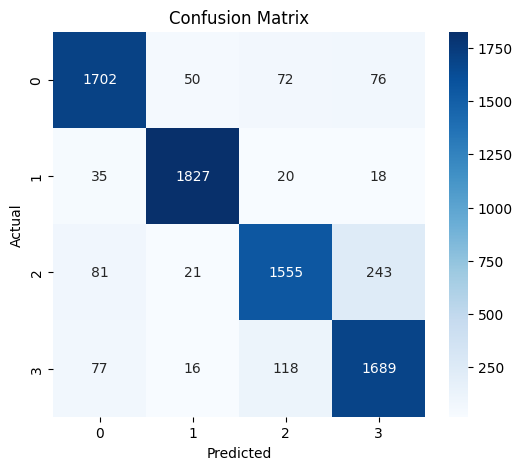

In [86]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_mlp_w2v.png')
plt.show()

Per each sample ,the FLOPs carried can be calculated by the formula below. This is entirely dependent on the architecture.
$$ FLOPs=2×Input Dimension x Output Dimension $$ 
per layer

In [87]:
import tensorflow as tf
def analytical_flops(model):
    flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dense):
            in_features = layer.input_shape[-1]
            out_features = layer.output_shape[-1]
            flops += 2 * in_features * out_features
    return flops

flops = analytical_flops(mlp_w2v)
print(f"Analytical FLOPs: {flops} FLOPs")


Analytical FLOPs: 13173760 FLOPs


In [88]:
results = {}
results[('Word2Vec','MLP Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_train_time},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':cpu_time_inf,
                                            "flops/sample": flops}}

### CNN Model:

In [89]:
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

embedding_dim = 128
filters = 128
kernel_size = 3

cnn_w2v = Sequential([
    Embedding(input_dim = vocab_size, output_dim = embedding_dim,
        weights = [embedding_matrix], input_length = max_len, trainable=False),

    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

cnn_w2v.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_w2v.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 200, 128)          5120000   
                                                                 
 conv1d_2 (Conv1D)           (None, 198, 128)          49280     
                                                                 
 global_max_pooling1d_2 (Glo  (None, 128)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_13 (Dense)            (None, 64)                8256      
                                                                 
 dropout_8 (Dropout)         (None, 64)                0         
                                                                 
 dense_14 (Dense)            (None, 4)                 260       
                                                      

In [90]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

history_w2v = cnn_w2v.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=1000
)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_train = cpu_end_time - cpu_start_time
cell_time_train =  end_time - start_time
print(cpu_time_train)
print(cell_time_train)

Epoch 1/5
108/108 [==============================] - 58s 523ms/step - loss: 0.4958 - accuracy: 0.8315 - val_loss: 0.2853 - val_accuracy: 0.8975
Epoch 2/5
108/108 [==============================] - 66s 611ms/step - loss: 0.3116 - accuracy: 0.8973 - val_loss: 0.2615 - val_accuracy: 0.9058
Epoch 3/5
108/108 [==============================] - 64s 592ms/step - loss: 0.2795 - accuracy: 0.9076 - val_loss: 0.2477 - val_accuracy: 0.9094
Epoch 4/5
108/108 [==============================] - 39s 361ms/step - loss: 0.2581 - accuracy: 0.9138 - val_loss: 0.2355 - val_accuracy: 0.9136
Epoch 5/5
108/108 [==============================] - 41s 382ms/step - loss: 0.2413 - accuracy: 0.9187 - val_loss: 0.2335 - val_accuracy: 0.9128
1666.796875
268.02888226509094
CPU times: total: 27min 46s
Wall time: 4min 28s


In [91]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

y_pred_probs = cnn_w2v.predict(X_test_pad)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_inf = cpu_end_time - cpu_start_time
cell_time_inf =  end_time - start_time
print(cpu_time_inf)
print(cell_time_inf)

238/238 [==============================] - 3s 11ms/step
10.0
3.1453099250793457
CPU times: total: 10 s
Wall time: 3.15 s


In [92]:
y_pred_test = np.argmax(y_pred_probs, axis=1)

y_train_probs = cnn_w2v.predict(X_train_pad)
y_train_pred = np.argmax(y_train_probs,axis=1)

3750/3750 [==============================] - 59s 16ms/step


In [93]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_report = classification_report(y_train, y_train_pred)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.925625

 Training F1 Score 0.9253299897002434

 Training Classification Report               precision    recall  f1-score   support

           0       0.94      0.91      0.93     30000
           1       0.95      0.99      0.97     30000
           2       0.92      0.88      0.90     30000
           3       0.89      0.92      0.90     30000

    accuracy                           0.93    120000
   macro avg       0.93      0.93      0.93    120000
weighted avg       0.93      0.93      0.93    120000



In [94]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred_test)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.9111842105263158

 Test F1 Score 0.9107940298076342

 Test Classification Report               precision    recall  f1-score   support

           0       0.93      0.90      0.92      1900
           1       0.95      0.99      0.97      1900
           2       0.89      0.86      0.87      1900
           3       0.88      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



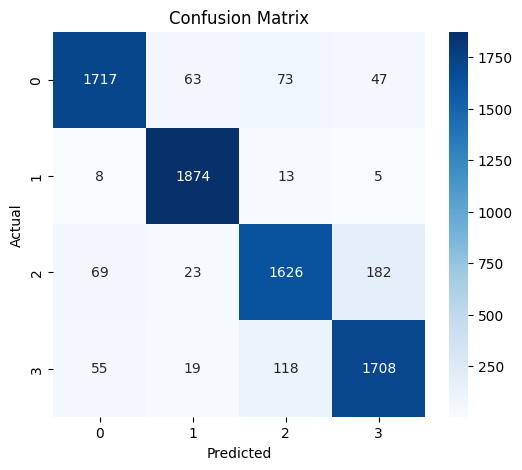

In [96]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_cnn_w2v.png')
plt.show()

Per each sample ,the FLOPs carried can be calculated by the formula below. This is entirely dependent on the architecture.
$$FLOPs=2×(sequence length)×(kernel size)×(embedding dim)×(filters)$$

In [97]:
flops = 2 * 200 * 3 * 128 * 128
print("The FLOPs carried out per sample is: ", flops)

The FLOPs carried out per sample is:  19660800


In [98]:
results[('Word2Vec','CNN Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_time_train},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':cpu_time_inf,
                                            "flops/sample": flops}}

In [99]:
len(sentences)

120000

### SGNS - Word2Vec from scratch.

In [100]:
import math
import random
import numpy as np
from collections import Counter
import re

In [101]:
corpus_text = " ".join(train_df['text'].astype(str).tolist())
print("Corpus Length: ",len(corpus_text))

Corpus Length:  28497302


In [102]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 40000
tokenizer = Tokenizer(num_words = vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts([corpus_text])

seq = tokenizer.texts_to_sequences([corpus_text])[0]

In [103]:
print(corpus_text[:50])
print(seq[:10])


Wall St. Bears Claw Back Into the Black (Reuters) 
[443, 442, 1682, 14529, 109, 65, 2, 851, 22, 22]


In [104]:
index_to_word = tokenizer.index_word

tokens = [index_to_word[i] for i in seq if i in index_to_word]
print(tokens[:10])

['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters']


In [105]:
from collections import Counter

MIN_COUNT = 3

freq = Counter(tokens)
vocab = [w for w,c in freq.items() if c >= MIN_COUNT]

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

V = len(vocab)
print("SGNS Vocabulary Size: ",V)

SGNS Vocabulary Size:  37034


In [106]:
token_ids = [word2idx[w] for w in tokens if w in word2idx]

In [107]:
WINDOW = 5              # use a smaller window for stability
EMBED_DIM = 128
NEG_K = 5
EPOCHS = 5
INITIAL_LR = 0.025
SUBSAMPLE_T = 1e-5

def generate_pairs(token_ids, window_size = 5):
    corpus_len = len(token_ids)
    for i, center in enumerate(token_ids):
        left = max(0,i-WINDOW)
        right = min(corpus_len, i+WINDOW +1)
        for j in range(left,right):
            if j!= i:
                yield center, token_ids[j]

def sigmoid(x):
    x = np.clip(x, -8,8)
    return 1 / (1 + np.exp(-x))

def sample_negatives(cdf, k):
    r = np.random.rand(k)
    return np.searchsorted(cdf, r)

def subsample_tokens(token_ids, freq, total_tokens, t=SUBSAMPLE_T):
    freqs = np.array([freq[i] / total_tokens for i in range(len(freq))])

    p_drop = 1 - np.sqrt(t/freqs)
    p_drop = np.clip(p_drop, 0,1)

    new_tokens = [wid for wid in token_ids if random.random() > p_drop[wid]]
    return new_tokens

def build_negative_sampling_table(freq):
    freq_arr = np.array(freq, dtype=np.float64)
    p_dist = freq_arr ** 0.75
    p_dist /= p_dist.sum()
    cdf = np.cumsum(p_dist)
    return cdf

In [108]:
import time
def train_sgns(token_ids, freq, vocab_size):

    print("Applying subsampling")
    total_tokens = len(token_ids)
    token_ids = subsample_tokens(token_ids, freq, total_tokens)
    print("Tokens after subsampling:",len(token_ids))

    cdf = build_negative_sampling_table(freq)

    W_in = np.random.uniform(-0.5/EMBED_DIM, 0.5/EMBED_DIM, (vocab_size, EMBED_DIM))
    W_out = np.zeros((vocab_size, EMBED_DIM))

    total_pairs_est = len(token_ids) * (2* WINDOW)
    print("Estimated total pairs:", total_pairs_est)

    for epoch in range(EPOCHS):
        print(f"\n Epoch {epoch+1}/ {EPOCHS}  ")
        total_loss = 0 
        count = 0
        start_time = time.time()
        for center, context in generate_pairs(token_ids, WINDOW):
            
    
            progress = count / (total_pairs_est + 1)
            LR = INITIAL_LR * max(0.0001, (1 - progress))

            # negative samples
            negs = sample_negatives(cdf, NEG_K)

            v_c   = W_in[center]
            v_pos = W_out[context]
            v_neg = W_out[negs]    # shape: (K, EMBED_DIM)

            # positive pair
            score_pos = sigmoid(np.dot(v_c, v_pos))
            g_pos = score_pos - 1

            # negative pairs
            score_neg = sigmoid(v_neg @ v_c)
            g_neg = score_neg

            # UPDATE center embedding
            W_in[center] -= LR * (g_pos * v_pos + (g_neg[:, None] * v_neg).sum(axis=0))

            # UPDATE positive context embedding
            W_out[context] -= LR * (g_pos * v_c)

            # UPDATE negative samples
            W_out[negs] -= LR * (g_neg[:, None] * v_c)

            # CLIP embedding values (CRITICAL)
            if count % 10000 == 0:
                np.clip(W_in,  -2.0, 2.0, out=W_in)
                np.clip(W_out, -2.0, 2.0, out=W_out)

            # LOSS
            loss = -np.log(score_pos + 1e-10) - np.sum(np.log(1 - score_neg + 1e-10))
            total_loss += loss

            count += 1
            if count % 200000 == 0:
                end_time = time.time()
                print("Time taken for 200k end_time-start_time", end_time-start_time)
                start_time = time.time()
                print(f"Processed {count}, LR={LR:.5f}, avg loss={total_loss/count:.4f}")

        print("Epoch average loss:", total_loss/count)

    return W_in, W_out
        

In [109]:
# Build vocab
word_counter = Counter(tokens)
vocab = [w for w,c in word_counter.items() if c >= MIN_COUNT]

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(vocab)

# Build token-id sequence
token_ids = [word2idx[w] for w in tokens if w in word2idx]

# Build freq_list (important)
freq_list = [0] * vocab_size
for w,i in word2idx.items():
    freq_list[i] = word_counter[w]

# Now run SGNS
W_in, W_out = train_sgns(token_ids, freq_list, vocab_size)


Applying subsampling
Tokens after subsampling: 1252199
Estimated total pairs: 12521990

 Epoch 1/ 5  
Time taken for 200k end_time-start_time 21.564414024353027
Processed 200000, LR=0.02460, avg loss=4.1465
Time taken for 200k end_time-start_time 9.766578674316406
Processed 400000, LR=0.02420, avg loss=3.9187
Time taken for 200k end_time-start_time 8.921405553817749
Processed 600000, LR=0.02380, avg loss=3.6843
Time taken for 200k end_time-start_time 9.210193395614624
Processed 800000, LR=0.02340, avg loss=3.5012
Time taken for 200k end_time-start_time 8.959543228149414
Processed 1000000, LR=0.02300, avg loss=3.3738
Time taken for 200k end_time-start_time 9.011648654937744
Processed 1200000, LR=0.02260, avg loss=3.2794
Time taken for 200k end_time-start_time 9.057761430740356
Processed 1400000, LR=0.02220, avg loss=3.2017
Time taken for 200k end_time-start_time 9.28623104095459
Processed 1600000, LR=0.02181, avg loss=3.1395
Time taken for 200k end_time-start_time 10.140411615371704
Pro

In [110]:
embedding_dim = W_in.shape[1]

keras_vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((keras_vocab_size, embedding_dim), dtype=np.float32)

for word, keras_idx in tokenizer.word_index.items():
    if word in word2idx:           # word appears in SGNS vocabulary
        sgns_idx = word2idx[word]  # index into your W_in
        embedding_matrix[keras_idx] = W_in[sgns_idx]


### MLP Model with Word2Vec Scratch.

In [111]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout

max_len = 200   # your input sequence length
num_classes = 4 # AG-NEWS categories

mlp_model = Sequential([
    Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False       # freeze SGNS weights
    ),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])


In [112]:
mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [113]:
%%time 
import time
cpu_start_time = time.process_time()
history = mlp_model.fit(
    X_train_pad, y_train_cat,
    epochs=5,
    batch_size=1024,
    validation_split=0.1
)
cpu_end_time = time.process_time()
cpu_train_time = cpu_end_time - cpu_start_time
print(cpu_train_time)


Epoch 1/5
106/106 [==============================] - 9s 84ms/step - loss: 0.3885 - accuracy: 0.8660 - val_loss: 0.2940 - val_accuracy: 0.8886
Epoch 2/5
106/106 [==============================] - 9s 81ms/step - loss: 0.2793 - accuracy: 0.9029 - val_loss: 0.2875 - val_accuracy: 0.8934
Epoch 3/5
106/106 [==============================] - 9s 82ms/step - loss: 0.2453 - accuracy: 0.9141 - val_loss: 0.2854 - val_accuracy: 0.8938
Epoch 4/5
106/106 [==============================] - 9s 82ms/step - loss: 0.2167 - accuracy: 0.9233 - val_loss: 0.2917 - val_accuracy: 0.8942
Epoch 5/5
106/106 [==============================] - 9s 85ms/step - loss: 0.1902 - accuracy: 0.9320 - val_loss: 0.3042 - val_accuracy: 0.8935
481.34375
CPU times: total: 8min 1s
Wall time: 44.3 s


In [114]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

y_pred_probs = mlp_model.predict(X_test_pad)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_inf = cpu_end_time - cpu_start_time
cell_time_inf =  end_time - start_time
print(cpu_time_inf)
print(cell_time_inf)

238/238 [==============================] - 1s 6ms/step
6.453125
1.4686636924743652
CPU times: total: 6.45 s
Wall time: 1.47 s


In [115]:
y_pred_test = np.argmax(y_pred_probs, axis=1)

y_train_probs = mlp_model.predict(X_train_pad)
y_train_pred = np.argmax(y_train_probs,axis=1)

3750/3750 [==============================] - 20s 5ms/step


In [116]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_report = classification_report(y_train, y_train_pred)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.9458916666666667

 Training F1 Score 0.9458936866233522

 Training Classification Report               precision    recall  f1-score   support

           0       0.94      0.95      0.95     30000
           1       0.99      0.98      0.98     30000
           2       0.95      0.91      0.92     30000
           3       0.91      0.94      0.93     30000

    accuracy                           0.95    120000
   macro avg       0.95      0.95      0.95    120000
weighted avg       0.95      0.95      0.95    120000



In [117]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred_test)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.8914473684210527

 Test F1 Score 0.8915315779921515

 Test Classification Report               precision    recall  f1-score   support

           0       0.88      0.91      0.90      1900
           1       0.97      0.95      0.96      1900
           2       0.88      0.83      0.85      1900
           3       0.84      0.88      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



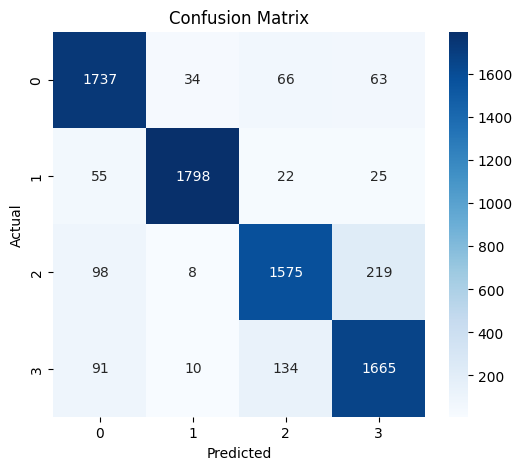

In [118]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_mlp_w2vscratch.png')
plt.show()

In [119]:
import tensorflow as tf
def analytical_flops(model):
    flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dense):
            in_features = layer.input_shape[-1]
            out_features = layer.output_shape[-1]
            flops += 2 * in_features * out_features
    return flops

flops = analytical_flops(mlp_model)
print(f"Analytical FLOPs: {flops} FLOPs")


Analytical FLOPs: 13173760 FLOPs


In [120]:
results[('Word2Vec Scratch','MLP Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_train_time},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':cpu_time_inf,
                                            "flops/sample": flops}}

### CNN Model - With Word2Vec Scratch.

In [121]:
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

embedding_dim = 128
filters = 128
kernel_size = 3

cnn_model = Sequential([
    Embedding(input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False ),

    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_7 (Embedding)     (None, 200, 128)          9004288   
                                                                 
 conv1d_3 (Conv1D)           (None, 198, 128)          49280     
                                                                 
 global_max_pooling1d_3 (Glo  (None, 128)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_18 (Dense)            (None, 64)                8256      
                                                                 
 dropout_11 (Dropout)        (None, 64)                0         
                                                                 
 dense_19 (Dense)            (None, 4)                 260       
                                                      

In [122]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

history_w2v_cnn = cnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=1000
)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_train = cpu_end_time - cpu_start_time
cell_time_train =  end_time - start_time
print(cpu_time_train)
print(cell_time_train)

Epoch 1/5
108/108 [==============================] - 41s 375ms/step - loss: 0.5174 - accuracy: 0.8333 - val_loss: 0.3040 - val_accuracy: 0.8916
Epoch 2/5
108/108 [==============================] - 37s 345ms/step - loss: 0.3190 - accuracy: 0.8958 - val_loss: 0.2882 - val_accuracy: 0.8923
Epoch 3/5
108/108 [==============================] - 25s 234ms/step - loss: 0.2934 - accuracy: 0.9037 - val_loss: 0.2751 - val_accuracy: 0.9005
Epoch 4/5
108/108 [==============================] - 25s 235ms/step - loss: 0.2768 - accuracy: 0.9088 - val_loss: 0.2668 - val_accuracy: 0.9022
Epoch 5/5
108/108 [==============================] - 34s 320ms/step - loss: 0.2607 - accuracy: 0.9136 - val_loss: 0.2456 - val_accuracy: 0.9097
1595.796875
163.29528093338013
CPU times: total: 26min 35s
Wall time: 2min 43s


In [123]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

y_pred_probs = cnn_model.predict(X_test_pad)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_inf = cpu_end_time - cpu_start_time
cell_time_inf =  end_time - start_time
print(cpu_time_inf)
print(cell_time_inf)

238/238 [==============================] - 2s 8ms/step
11.78125
2.184290885925293
CPU times: total: 11.8 s
Wall time: 2.18 s


In [124]:
y_pred_test = np.argmax(y_pred_probs, axis=1)

y_train_probs = cnn_model.predict(X_train_pad)
y_train_pred = np.argmax(y_train_probs,axis=1)

3750/3750 [==============================] - 31s 8ms/step


In [125]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_report = classification_report(y_train, y_train_pred)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.9189833333333334

 Training F1 Score 0.9189767616846327

 Training Classification Report               precision    recall  f1-score   support

           0       0.94      0.90      0.92     30000
           1       0.96      0.98      0.97     30000
           2       0.88      0.90      0.89     30000
           3       0.89      0.90      0.89     30000

    accuracy                           0.92    120000
   macro avg       0.92      0.92      0.92    120000
weighted avg       0.92      0.92      0.92    120000



In [126]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred_test)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.9080263157894737

 Test F1 Score 0.908019966908948

 Test Classification Report               precision    recall  f1-score   support

           0       0.93      0.89      0.91      1900
           1       0.96      0.97      0.97      1900
           2       0.86      0.88      0.87      1900
           3       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [127]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_cnn_w2vscratch.png')
plt.show()

NameError: name 'y_pred' is not defined

In [ ]:
flops = 2 * 200 * 3 * 128 * 128
print("The FLOPs carried out per sample is: ", flops)

In [ ]:
results[('Word2Vec Scratch','CNN Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_time_train},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':cpu_time_inf,
                                            "flops/sample": flops}}

## Tabulate:

In [ ]:
# create DataFrame
import pandas as pd

# flatten nested dict into a list of rows
rows = []

for (vectorizer, model), metrics in results.items():
    row = {
        "Vectorizer": vectorizer,
        "Model": model,
        "Train_Accuracy": metrics["Train"]["accuracy"],
        "Train_F1": metrics["Train"]["f1_score"],
        "Test_Accuracy": metrics["Test"]["accuracy"],
        "Test_F1": metrics["Test"]["f1_score"],
        "Inference_Time": metrics["Test"].get("inference_time", None),
        "FLOPs_per_Sample": metrics["Test"].get("flops/sample", None),
        "Training_Time": metrics['Train'].get('training_time',None)
    }
    rows.append(row)

# create DataFrame
df_results = pd.DataFrame(rows)

# optional: set a clean display order
df_results = df_results[
    ["Vectorizer", "Model", "Train_Accuracy", "Train_F1",
     "Test_Accuracy", "Test_F1", "Inference_Time", "FLOPs_per_Sample","Training_Time"]
]

print(df_results)

In [ ]:
results = pd.read_csv('datasets/results.csv')

df = pd.concat([results, df_results], axis=0,ignore_index=True)

In [ ]:
df.drop(['Unnamed: 0','index'], axis=1)

In [ ]:
df.to_csv('datasets/results.csv')
df_results.to_csv('datasets/w2vec_emb.csv')

In [ ]:
df = pd.read_csv('datasets/results.csv')
df = df[['Vectorizer','Model','Train_Accuracy','Train_F1','Test_Accuracy','Test_F1','Inference_Time','FLOPs_per_Sample','Training_Time']].dropna().reset_index().drop('index',axis=1)

In [ ]:
df.to_csv('datasets/results.csv',index=False)